In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

tickers = ['ENEL.MI', 'ISP.MI', 'ENI.MI', 'AIR.PA', 'MC.PA', 'OR.PA', 
           'SAP.DE', 'SIE.DE', 'ALV.DE', 'IBE.MC', 'SAN.MC', 'ASML.AS']

series_list = []
for t in tickers:
    try:
        data = yf.Ticker(t).history(period="5y")
        if not data.empty and 'Close' in data.columns:
            series_list.append(data['Close'].rename(t))
    except:
        pass

prices = pd.concat(series_list, axis=1).fillna(method='ffill').dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

# Defining Green (Low ESG Risk) stocks
# Based on the ESG ranking computed previously
green_tickers = ['SAP.DE', 'ASML.AS', 'MC.PA', 'IBE.MC', 'SIE.DE', 'OR.PA']

# Selecting returns of sustainable companies only
returns_green = log_returns[green_tickers]

In [2]:
# 1. Preliminary calculations: expected returns and covariance matrix (annualized)
mean_returns = returns_green.mean() * 252
cov_matrix = returns_green.cov() * 252

# 2. Function to compute portfolio performance given weights
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0):
    # Expected portfolio return
    returns = np.sum(mean_returns * weights)
    # Portfolio volatility
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    # Sharpe Ratio
    sharpe_ratio = (returns - risk_free_rate) / std_dev
    return returns, std_dev, sharpe_ratio

# 3. Objective function: minimizing negative Sharpe ratio
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0):
    return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]

# 4. Constraints and bounds
# Constraint: weights must sum to 1 (fully invested portfolio)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds: weights between 0 and 1 (no short selling)
bounds = tuple((0.0, 1.0) for asset in range(len(green_tickers)))

# Initial guess: equally weighted portfolio
init_guess = len(green_tickers) * [1. / len(green_tickers),]

print("Optimization setup completed. Ready to run.")

Optimization setup completed. Ready to run.


In [4]:
# Running optimization using Sequential Least Squares Programming (SLSQP)
optimized = sco.minimize(negative_sharpe, init_guess, args=(mean_returns, cov_matrix),
                         method='SLSQP', bounds=bounds, constraints=constraints)

# Extracting optimal weights
optimal_weights = optimized.x

# Computing portfolio performance metrics
opt_ret, opt_vol, opt_sharpe = portfolio_performance(optimal_weights, mean_returns, cov_matrix)

# Displaying results in a clean format
print("="*50)
print("OPTIMAL PORTFOLIO ALLOCATION (Max Sharpe Ratio)")
print("="*50)
for ticker, weight in zip(green_tickers, optimal_weights):
    # Mostriamo solo le allocazioni superiori allo 0.1% per pulizia
    if weight > 0.001:
        print(f" • {ticker}: {weight*100:.2f}%")

print("-" * 50)
print(f"Expected Annual Return: {opt_ret * 100:.2f}%")
print(f"Annual Volatility: {opt_vol * 100:.2f}%")
print(f"Sharpe Ratio: {opt_sharpe:.4f}")
print("="*50)

OPTIMAL PORTFOLIO ALLOCATION (Max Sharpe Ratio)
 • SAP.DE: 0.66%
 • ASML.AS: 14.98%
 • IBE.MC: 83.34%
 • SIE.DE: 1.02%
--------------------------------------------------
Expected Annual Return: 15.76%
Annual Volatility: 17.58%
Sharpe Ratio: 0.8963


Generating 5000 random portfolio weight combinations...


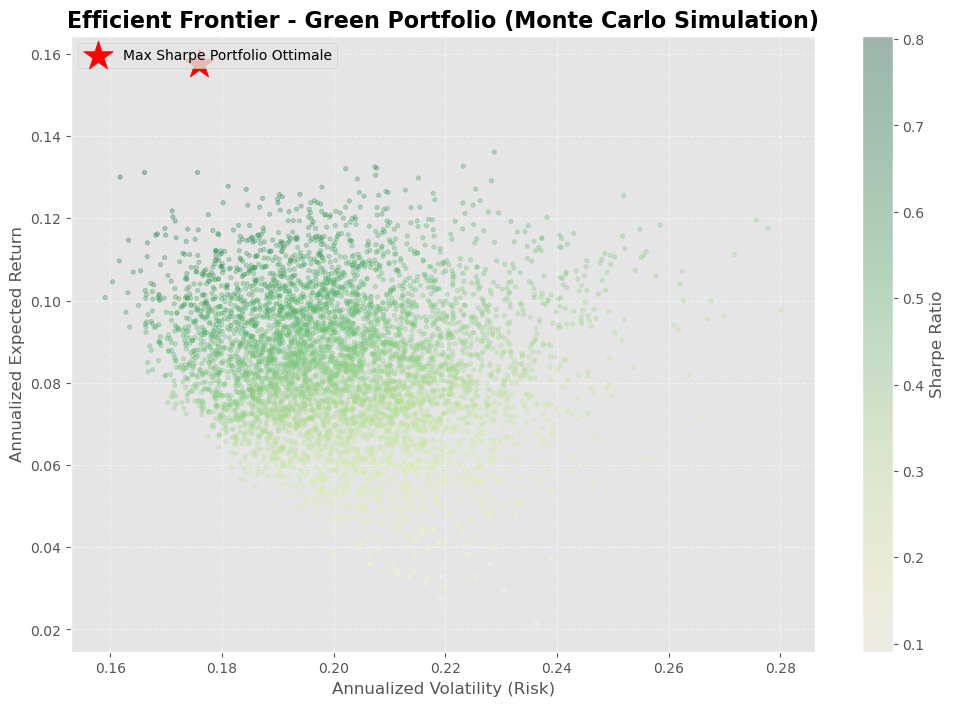

In [5]:
# 1. Monte Carlo simulation setup
num_portfolios = 5000
results = np.zeros((3, num_portfolios))

# 2. Generating 5000 random portfolio weight combinations
print("Generating 5000 random portfolio weight combinations...")
for i in range(num_portfolios):
    weights = np.random.random(len(green_tickers))
    weights /= np.sum(weights) # Normalizing to 100%
    
    port_ret, port_std, port_sharpe = portfolio_performance(weights, mean_returns, cov_matrix)
    
    results[0,i] = port_std    # X-axis: Risk
    results[1,i] = port_ret    # Y-axis: Return
    results[2,i] = port_sharpe # Color: Sharpe Ratio

# 3. Creating the Efficient Frontier plot
plt.figure(figsize=(12, 8))
# Plot portfolio cloud (colored by Sharpe Ratio)
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGn', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# 4. Adding Max Sharpe
plt.scatter(opt_vol, opt_ret, marker='*', color='red', s=500, label='Max Sharpe Portfolio Ottimale')

# Formatting
plt.title('Efficient Frontier - Green Portfolio (Monte Carlo Simulation)', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Starting optimization and Monte Carlo simulation for the Brown Portfolio...


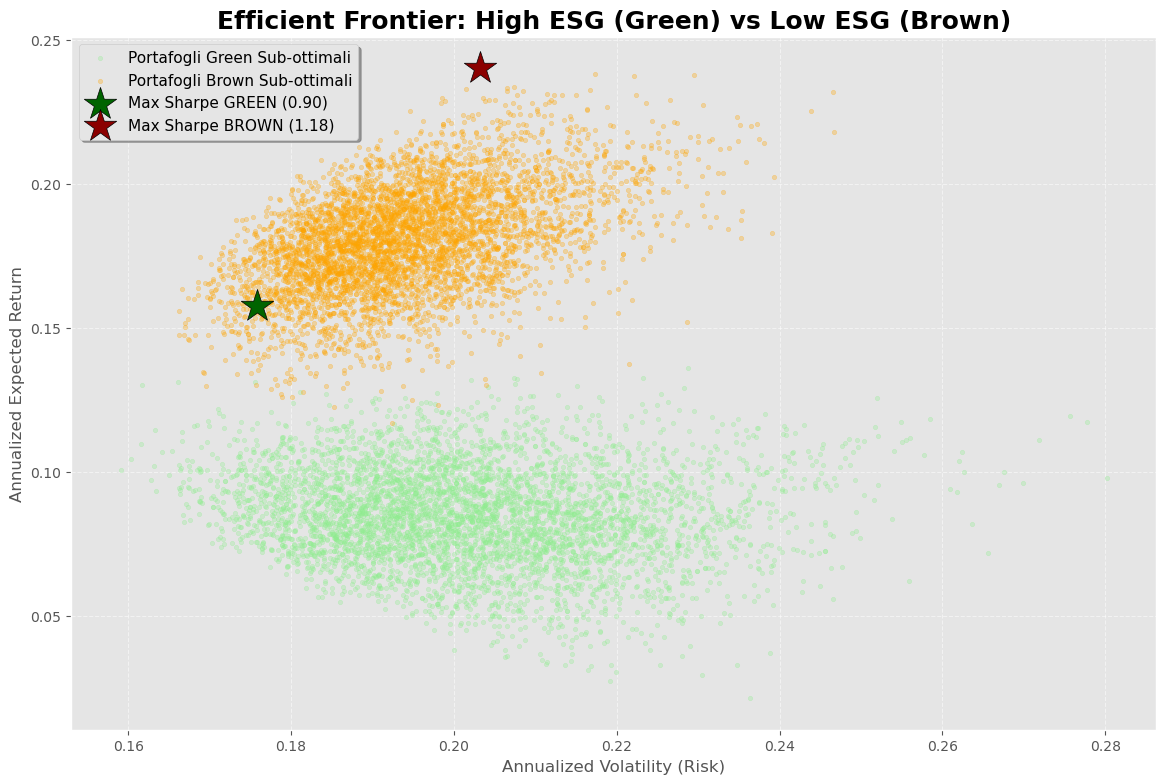

OPTIMAL BROWN PORTFOLIO ALLOCATION
 • ALV.DE: 3.20%
 • ISP.MI: 17.06%
 • SAN.MC: 21.13%
 • ENI.MI: 58.61%
--------------------------------------------------
Annualized Volatility (Risk): 20.32%
Expected Annual Return: 24.03%
Sharpe Ratio: 1.1823


In [8]:
print("Starting optimization and Monte Carlo simulation for the Brown Portfolio...")

# 1. Defining Brown tickers (the lower half of the ESG ranking)
brown_tickers = ['ALV.DE', 'ISP.MI', 'ENEL.MI', 'AIR.PA', 'SAN.MC', 'ENI.MI']
returns_brown = log_returns[brown_tickers]

mean_returns_b = returns_brown.mean() * 252
cov_matrix_b = returns_brown.cov() * 252

# 2. Optimization (Max Sharpe) for the Brown Portfolio
init_guess_b = len(brown_tickers) * [1. / len(brown_tickers),]
bounds_b = tuple((0.0, 1.0) for asset in range(len(brown_tickers)))

optimized_b = sco.minimize(negative_sharpe, init_guess_b, args=(mean_returns_b, cov_matrix_b),
                           method='SLSQP', bounds=bounds_b, constraints=constraints)

optimal_weights_b = optimized_b.x
opt_ret_b, opt_vol_b, opt_sharpe_b = portfolio_performance(optimal_weights_b, mean_returns_b, cov_matrix_b)

# 3. Monte Carlo simulation for the Brown Portfolio
results_b = np.zeros((3, num_portfolios))
for i in range(num_portfolios):
    weights = np.random.random(len(brown_tickers))
    weights /= np.sum(weights)
    p_ret, p_std, p_sharpe = portfolio_performance(weights, mean_returns_b, cov_matrix_b)
    results_b[0,i] = p_std
    results_b[1,i] = p_ret
    results_b[2,i] = p_sharpe

# 4. Final comparison plot
plt.figure(figsize=(14, 9))

# Plot Green portfolio cloud
plt.scatter(results[0,:], results[1,:], c='lightgreen', marker='o', s=10, alpha=0.3, label='Portafogli Green Sub-ottimali')
# Plot Brown portfolio portfolio cloud
plt.scatter(results_b[0,:], results_b[1,:], c='orange', marker='o', s=10, alpha=0.3, label='Portafogli Brown Sub-ottimali')

# Optimal portfolio markers
plt.scatter(opt_vol, opt_ret, marker='*', color='darkgreen', s=600, edgecolors='black', label=f'Max Sharpe GREEN ({opt_sharpe:.2f})')
plt.scatter(opt_vol_b, opt_ret_b, marker='*', color='darkred', s=600, edgecolors='black', label=f'Max Sharpe BROWN ({opt_sharpe_b:.2f})')

# Formatting
plt.title('Efficient Frontier: High ESG (Green) vs Low ESG (Brown)', fontsize=18, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('frontier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Printing Brown portfolio results for comparison
print("="*50)
print("OPTIMAL BROWN PORTFOLIO ALLOCATION")
print("="*50)
for ticker, weight in zip(brown_tickers, optimal_weights_b):
    if weight > 0.001:
        print(f" • {ticker}: {weight*100:.2f}%")
print("-" * 50)
print(f"Annualized Volatility (Risk): {opt_vol_b*100:.2f}%")
print(f"Expected Annual Return: {opt_ret_b*100:.2f}%")
print(f"Sharpe Ratio: {opt_sharpe_b:.4f}")